# Tweets de Política en España


Librerías

In [7]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import Counter

# Plot libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Text analysis API's
import re
import spacy
import nltk
import unicodedata
from nltk.corpus import stopwords
from nltk import TweetTokenizer
from spacy.lang.es import Spanish

# Preprocessin API´s
from sklearn.preprocessing import LabelEncoder 
from sklearn import preprocessing

# Regularization API´s 
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score, ShuffleSplit

# Feature extration API´s
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
# Machine Learning Methods 

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn import tree

# Metrics Libraries
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score

In [8]:
nlp = spacy.load('es_core_news_sm')

## Obtain information

In [9]:
tweets_politica = "../data/tweets_politica_kaggle.csv"
data = pd.read_csv(
    tweets_politica,
    sep="\t",
    engine="python",
    quoting=3,         
    on_bad_lines="skip"
)
data

,cuenta,partido,timestamp,tweet
0,a34133350b0605cb24081843f63176ca,psoe,1.363973e+09,@vesteve3 @manubenas @ccoo_rm @desobediencia_ ...
1,a34133350b0605cb24081843f63176ca,psoe,1.364061e+09,"""“@kirovast: @Hugo_Moran muy fan de la """"radic..."
2,a34133350b0605cb24081843f63176ca,psoe,1.364117e+09,@ALTAS_PRESIONES Nuevos dueños para las renova...
3,a34133350b0605cb24081843f63176ca,psoe,1.364121e+09,@jumanjisolar @solartradex @josea_dolera El di...
4,a34133350b0605cb24081843f63176ca,psoe,1.364153e+09,“@cesarnayu: https://t.co/J4OTXj1x7w … Por fav...
...,...,...,...,...
245784,0f73ee4d01daad6c58cda2f32bfd6170,ciudadanos,1.679571e+09,Acaba la legislatura. Final de etapa y buen mo...
245785,2a5fcd1034beb5bd30bf5a1528008d81,psoe,1.679572e+09,Un placer inaugurar la jornada #NextGeneration...
245786,561b1a4d4369a0116ac5eba469f28bc0,psoe,1.679572e+09,Y esto también es el PP https://t.co/CaOTdTWnXB
245787,42acd1f0c1c51732519ad0d533573359,pp,1.679572e+09,Actualización: Los 3 violadores ya han sido pu...


In [10]:
data.shape

(245789, 4)

Normalizacion de Datos

In [11]:
data["fecha"] = pd.to_datetime(data["timestamp"], unit="s")
data["dia"] = data["fecha"].dt.date
data["hora"] = data["fecha"].dt.hour

**Conclusión**

In [12]:
data.columns

Index(['cuenta', 'partido', 'timestamp', 'tweet', 'fecha', 'dia', 'hora'], dtype='object')

In [13]:
data.head(10)

,cuenta,partido,timestamp,tweet,fecha,dia,hora
0,a34133350b0605cb24081843f63176ca,psoe,1.363973e+09,@vesteve3 @manubenas @ccoo_rm @desobediencia_ ...,2013-03-22 17:31:32,2013-03-22,17
1,a34133350b0605cb24081843f63176ca,psoe,1.364061e+09,"""“@kirovast: @Hugo_Moran muy fan de la """"radic...",2013-03-23 17:50:35,2013-03-23,17
2,a34133350b0605cb24081843f63176ca,psoe,1.364117e+09,@ALTAS_PRESIONES Nuevos dueños para las renova...,2013-03-24 09:20:04,2013-03-24,9
3,a34133350b0605cb24081843f63176ca,psoe,1.364121e+09,@jumanjisolar @solartradex @josea_dolera El di...,2013-03-24 10:29:27,2013-03-24,10
4,a34133350b0605cb24081843f63176ca,psoe,1.364153e+09,“@cesarnayu: https://t.co/J4OTXj1x7w … Por fav...,2013-03-24 19:18:12,2013-03-24,19
5,a34133350b0605cb24081843f63176ca,psoe,1.364154e+09,“@iAgua: http://t.co/6yMSNcV1UA” (El Gobierno ...,2013-03-24 19:37:56,2013-03-24,19
6,a34133350b0605cb24081843f63176ca,psoe,1.364155e+09,"""""""Cospedal: las crisis ya no afectan a España...",2013-03-24 19:53:43,2013-03-24,19
7,a34133350b0605cb24081843f63176ca,psoe,1.364202e+09,“@ventonoso: España importa ya energía de Port...,2013-03-25 08:57:42,2013-03-25,8
8,a34133350b0605cb24081843f63176ca,psoe,1.364207e+09,@elsoldemerix El Gobierno Andaluz presenta rec...,2013-03-25 10:24:23,2013-03-25,10
9,a34133350b0605cb24081843f63176ca,psoe,1.364211e+09,“@mjocaballero: Maria Dolores de Cospedal dema...,2013-03-25 11:28:23,2013-03-25,11


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245789 entries, 0 to 245788
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   cuenta     245789 non-null  object        
 1   partido    245789 non-null  object        
 2   timestamp  245789 non-null  float64       
 3   tweet      245789 non-null  object        
 4   fecha      245789 non-null  datetime64[ns]
 5   dia        245789 non-null  object        
 6   hora       245789 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(1), object(4)
memory usage: 12.2+ MB


## Scrub data

Series de Tiempo (Hora, Dia) versus Tweets

In [15]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Tweets por hora", "Tweets por día")
)

# Datos por hora
tweets_por_hora = data.groupby("hora").size().reset_index(name="conteo")

fig.add_trace(
    go.Scatter(x=tweets_por_hora["hora"], y=tweets_por_hora["conteo"], mode="lines"),
    row=1, col=1
)

# Datos por día
tweets_por_dia = data.groupby("dia").size().reset_index(name="conteo")

fig.add_trace(
    go.Scatter(x=tweets_por_dia["dia"], y=tweets_por_dia["conteo"], mode="lines"),
    row=1, col=2
)

fig.show()

## Explore patterns (EDA)

Acerca de los partidos politicos

In [16]:
tweet_por_partido = data.groupby("partido", as_index=False)['tweet'].count()
tweet_por_partido.head(10)

,partido,tweet
0,ciudadanos,38592
1,podemos,48808
2,pp,45480
3,psoe,61404
4,vox,51505


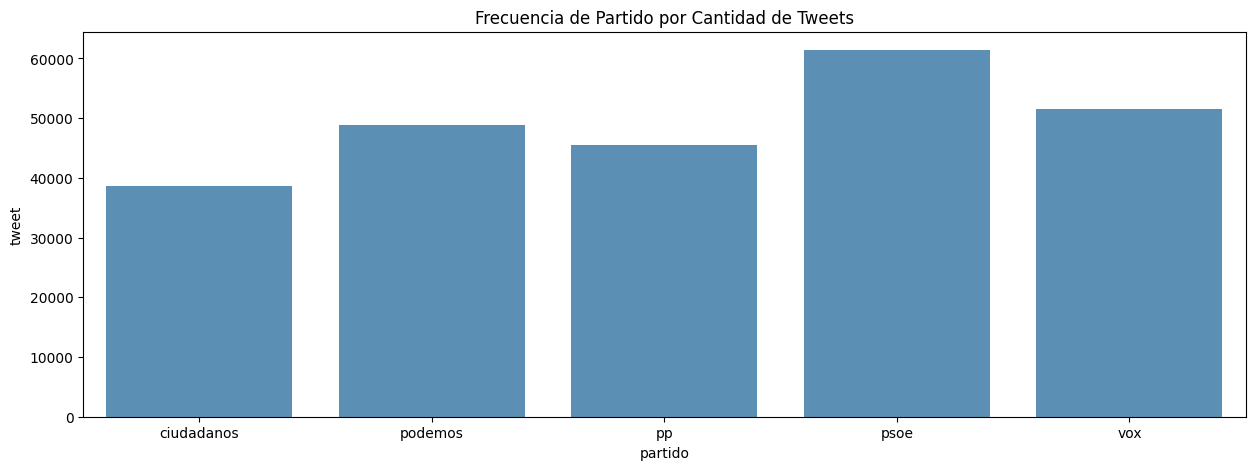

In [17]:
plt.figure(figsize=(15,5))
sns.barplot(data =tweet_por_partido, x = "partido", y = "tweet", alpha=0.8)
plt.title('Frecuencia de Partido por Cantidad de Tweets')
plt.show()

Universo de palabras del dataset: Tokenizacion

In [24]:
palabras = {}
for row in tqdm(data['tweet']):
    doc = nlp(row.lower())
    for token in doc:
        if token.is_alpha and not token.is_stop:
            if token.text in palabras:
                num_temp = int(palabras[token.text])
                palabras[token.text] = num_temp + 1
            else:
                palabras[token.text] = 1
# Guardar en archivo de texto, ordenado por frecuencia (mayor a menor)
with open('palabras.txt', 'w', encoding='utf-8') as f:
    for palabra, frecuencia in sorted(palabras.items(), key=lambda x: x[1], reverse=True):
        f.write(f"{palabra}: {frecuencia}\n")

print("Archivo guardado exitosamente.")

  8%|▊         | 18655/245789 [09:06<1:50:57, 34.12it/s]


KeyboardInterrupt: 

In [ ]:
sorted_words = sorted(palabras.items(), key=lambda x:x[1], reverse=True)
sorted_words

[('gobierno', 30248),
 ('españa', 25225),
 ('sánchez', 15261),
 ('gracias', 12964),
 ('pp', 12199),
 ('madrid', 10358),
 ('años', 10257),
 ('psoe', 10065),
 ('país', 9870),
 ('ley', 9361),
 ('españoles', 9129),
 ('vox', 8510),
 ('política', 7623),
 ('derechos', 7528),
 ('personas', 7093),
 ('libertad', 6840),
 ('partido', 6734),
 ('mujeres', 6389),
 ('trabajo', 6034),
 ('frente', 5925),
 ('seguir', 5740),
 ('social', 5616),
 ('vida', 5477),
 ('medidas', 5383),
 ('cs', 5324),
 ('apoyo', 5251),
 ('democracia', 5171),
 ('vía', 5109),
 ('europa', 5026),
 ('presidente', 5001),
 ('gente', 4972),
 ('millones', 4953),
 ('futuro', 4947),
 ('cataluña', 4726),
 ('año', 4595),
 ('igualdad', 4547),
 ('políticas', 4487),
 ('congreso', 4227),
 ('derecho', 4222),
 ('violencia', 4221),
 ('justicia', 4210),
 ('directo', 4194),
 ('familias', 4168),
 ('mañana', 4099),
 ('proyecto', 4055),
 ('crisis', 3957),
 ('empleo', 3945),
 ('ciudadanos', 3800),
 ('m', 3793),
 ('andalucía', 3785),
 ('mundo', 3763),
 ('

In [20]:
pos_freq = {}
for row in tqdm(data['tweet'].to_list()):
    doc = nlp(row.lower())
    for token in doc:
        if token.pos_ in pos_freq:
            value = pos_freq[token.pos_]
            pos_freq[token.pos_] = value + 1
        else:
            pos_freq[token.pos_] =  1

100%|██████████| 245789/245789 [1:30:08<00:00, 45.44it/s]  


In [21]:
df_pos = pd.DataFrame([[key, pos_freq[key]] for key in pos_freq.keys()], columns=['POS', 'Freq'])
df_pos.sort_values('Freq').tail(15)
df_pos = df_pos[:20]
df_pos.head(10)

,POS,Freq
0,PROPN,644740
1,ADJ,645779
2,VERB,901552
3,PUNCT,870524
4,NOUN,1817724
5,ADP,1233021
6,DET,1076390
7,PRON,392938
8,ADV,294861
9,AUX,318349


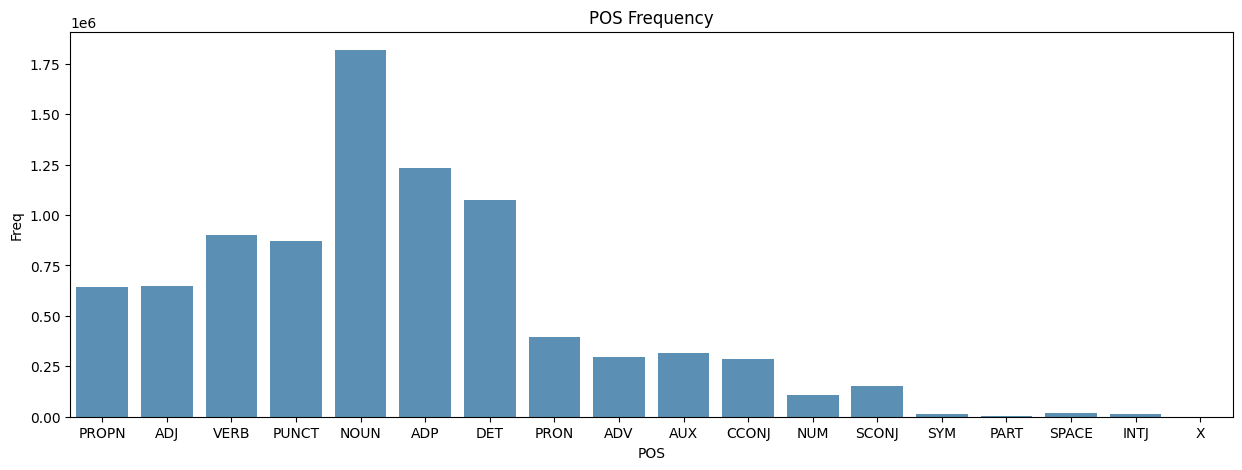

In [22]:
plt.figure(figsize=(15,5))
sns.barplot(data = df_pos, x = 'POS', y = 'Freq', alpha=0.8)
plt.title('POS Frequency')
plt.show()

In [ ]:
from logic.preprocessing import TextProcessing

tp = TextProcessing(lang='es')

    # 1. Limpiar
df = tp.clean_dataset(data, col='tweet', stopwords=False, keep_hashtag_text=True)

    # 2. Vectorizar
X = tp.fit_transform(df['clean'], max_features=10000, ngram_range=(1, 2))

    # 3. Ver tamaño del espacio
print(X.shape)

Tweets válidos: 245771 / 245789
Vocabulario: 10000 términos
['aa', 'abado', 'abajo', 'abalos', 'abandonado', 'abandonados', 'abandonar', 'abandono', 'abascal', 'abc', 'abierta', 'abiertas', 'abierto', 'abogacia', 'abogacia del', 'abogado', 'abogados', 'abordado', 'abordar', 'abordar la']
(245771, 10000)


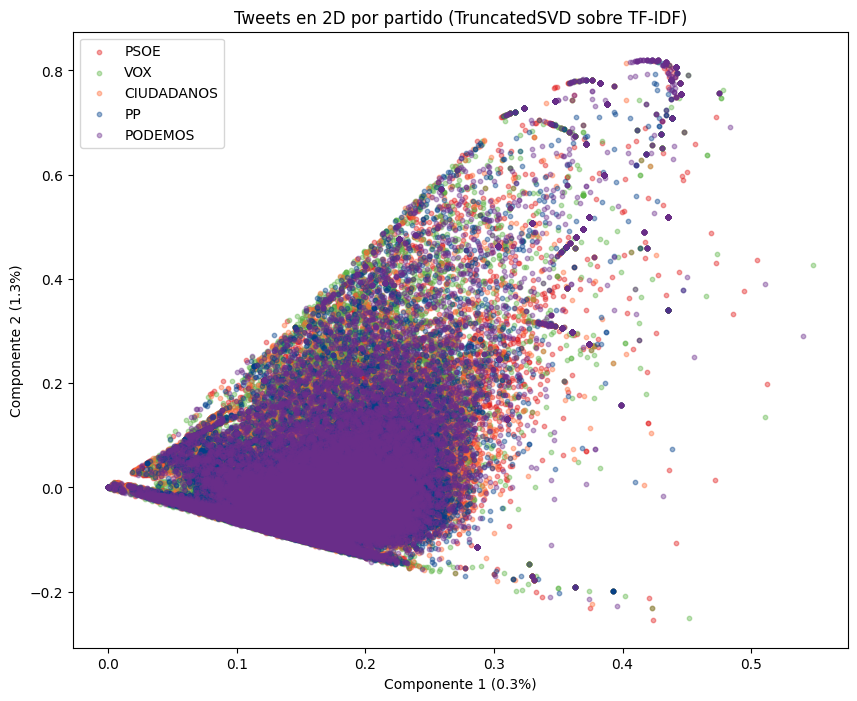

In [27]:
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

# Funciona directo sobre X sparse, sin convertir
svd = TruncatedSVD(n_components=2, random_state=42)
vectors_2d = svd.fit_transform(X)  # ← X original, sin .toarray()

colors = {
    'ciudadanos': '#FF6B35',
    'podemos':    '#6B2D8B',
    'pp':         '#003F8A',
    'psoe':       '#E31C1C',
    'vox':        '#5DB446',
}

plt.figure(figsize=(10, 8))
for partido in df['partido'].unique():
    mask = df['partido'] == partido
    plt.scatter(
        vectors_2d[mask, 0],
        vectors_2d[mask, 1],
        label=partido.upper(),
        color=colors[partido],
        alpha=0.4,
        s=10  # puntos más pequeños porque son 245k
    )

plt.legend()
plt.title('Tweets en 2D por partido (TruncatedSVD sobre TF-IDF)')
plt.xlabel(f'Componente 1 ({svd.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Componente 2 ({svd.explained_variance_ratio_[1]*100:.1f}%)')
plt.show()

In [ ]:
#Determinacion de datos


## Model construction